# Downloading the Data
Bring in the data in order to run it with the LSTM.

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

from datasets import load_dataset

ds = load_dataset("zh-plus/tiny-imagenet")

y_all = np.array(ds["train"]["label"])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

/Users/armindelmo/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/armindelmo/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
def prep(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

## Data Preparation
Since LSTMs are sequential, it is imperative that the date is flattened, and that it can be read properly.

In [8]:
# getting the dataset ready
def hf_to_tf(hf_split, batch_size = 64, image_size = (64,64), shuffle=False):
    def gen():
        for example in hf_split:
            img = example["image"].convert("RGB").resize(image_size)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            yield arr, np.int32(example["label"])

    output_signature = (
        tf.TensorSpec(shape=(image_size[0], image_size[1], 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    )

    ds_tf = tf.data.Dataset.from_generator(gen, output_signature=output_signature)
    if shuffle:
        ds_tf = ds_tf.shuffle(10000, reshuffle_each_iteration=True)
    ds_tf = ds_tf.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds_tf

train_ds = hf_to_tf(ds["train"], batch_size=64, image_size=(64, 64), shuffle=True)
test_ds = hf_to_tf(ds["valid"], batch_size=64, image_size=(64, 64), shuffle=False)


## LSTM 
We are going to use a Long term state memory device in order to train against the dataset we have.

In [6]:
def build_lstm_model(num_classes = 200):
    lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 3)),
    tf.keras.layers.Reshape((256, 48)),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    lstm.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

    return lstm

In [ ]:
num_classes = 200

print(tf.config.list_physical_devices("GPU"))
print(tf.config.list_logical_devices("GPU"))

fold_metrics = []
fold_p, fold_r, fold_f1 = [], [], []
y_all = np.array(ds["train"]["label"])

for fold, (train_index, valid_index) in enumerate(skf.split(np.zeros(len(y_all)), y_all), 1):
    print(f"\n=-=Fold {fold}=-=")

    train_fold = ds["train"].select(train_index.tolist())
    valid_fold = ds["train"].select(valid_index.tolist())

    train_ds_fold = hf_to_tf(train_fold, batch_size=64, image_size=(64,64), shuffle=True)
    valid_ds_fold = hf_to_tf(valid_fold, batch_size=64, image_size=(64,64), shuffle=False)

    lstm = build_lstm_model()
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=0.000001,
            verbose=1
        ),
        # change to your filepath
        tf.keras.callbacks.ModelCheckpoint(
            filepath="CHANGE TO YOUR FILEPATH",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        )
    ]
    
    # run it on the gpu
    with tf.device("/GPU:0"):
        history = lstm.fit(
            train_ds_fold.prefetch(tf.data.AUTOTUNE),
            validation_data=valid_ds_fold.prefetch(tf.data.AUTOTUNE),
            epochs=50,
            callbacks=callbacks,
            verbose=1
        )
        val_loss, val_acc = lstm.evaluate(valid_ds_fold.prefetch(tf.data.AUTOTUNE))
        fold_metrics.append(val_acc)
    
    val_loss, val_acc = lstm.evaluate(valid_ds_fold.prefetch(tf.data.AUTOTUNE), verbose = 0)

    # compute precision/recall/f1 for each fold
    y_true = np.concatenate([y.numpy() for _, y in valid_ds_fold], axis=0)
    y_prob = lstm.predict(valid_ds_fold.prefetch(tf.data.AUTOTUNE), verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    fold_p.append(p); fold_r.append(r); fold_f1.append(f1)

    print(f"Fold {fold} val_acc: {val_acc:.4f}, F1(w): {f1:.4f}, P(w): {p:.4f}, R(w): {r:.4f}")

print("CV precision mean/std   :", np.mean(fold_p), np.std(fold_p))
print("CV recall mean/std      :", np.mean(fold_r), np.std(fold_r))
print("CV F1(w) mean/std       :", np.mean(fold_f1), np.std(fold_f1))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[LogicalDevice(name='/device:GPU:0', device_type='GPU')]

=-=Fold 1=-=
Epoch 1/50


2026-05-03 11:31:08.148390: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


    731/Unknown - 26s 29ms/step - loss: 4.6912 - accuracy: 0.0204

KeyboardInterrupt: 

# Collecting Statistics

Now that we have ran all of the models, we are going to collect their statistics with scikit-learn.
We can accomplish this by collecting their accuracy from the validation set, and go from there.

157/157 [==============================] - 2s 11ms/step - loss: 5.8731 - accuracy: 0.0050


2026-05-03 11:33:13.499297: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 14010600073802967073
2026-05-03 11:33:13.499308: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 13477357163269685747
2026-05-03 11:33:13.499310: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 11930967603198819235
2026-05-03 11:33:13.499313: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 10733160643986017977
2026-05-03 11:33:13.499315: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 8147359250114980024


157/157 [==============================] - 2s 9ms/step
Weighted- Precision: 2.5e-05 Recall: 0.005 F1: 4.9751243781094526e-05


2026-05-03 11:33:16.484631: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 9417535130104376019
2026-05-03 11:33:16.484646: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 15279154540920722182


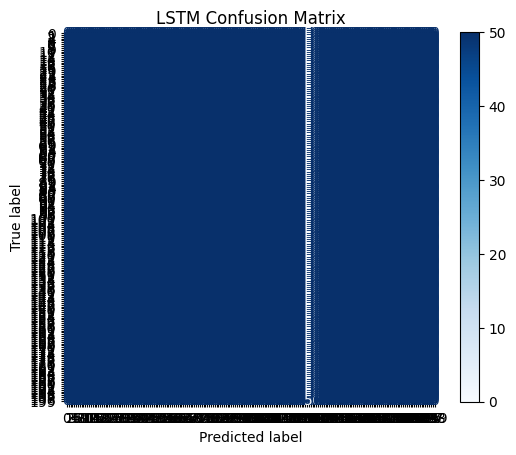

Testing >> Weighted- Precision: 2.5e-05 Recall: 0.005 F1 Score: 4.9751243781094526e-05


In [ ]:

# collecting results from the lstm
val_results = lstm.evaluate(test_ds.prefetch(tf.data.AUTOTUNE))

# using scikit-learn stuff
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

y_prob = lstm.predict(test_ds.prefetch(tf.data.AUTOTUNE), verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# 3) Aggregate metrics
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print("Weighted- Precision:", p_weighted, "Recall:", r_weighted, "F1:", f1_weighted)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(200))
display.plot(cmap=plt.cm.Blues)

plt.title("LSTM Confusion Matrix")
plt.show()

print("Testing >> Weighted- Precision:", p_weighted, "Recall:", r_weighted, "F1 Score:", f1_weighted)
